In [1]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

import dask
import dask.dataframe as dd
from dask.distributed import Client


### Load Outbreak Data and TLGRF Prediction Data

In [2]:
DATA_FOLDER = "../data"
COLORADO_DATA_FOLDER = os.path.join(DATA_FOLDER,"Colorado_Data")
COLORADO_DF_PATH = os.path.join(COLORADO_DATA_FOLDER,"Colorado_Outbreak_Data_2021-09-01.csv")
MASTER_FIPS_PATH = os.path.join(COLORADO_DATA_FOLDER,"county_fips_master.csv")

In [3]:
colorado_outbreaks = pd.read_csv("../data/colorado_outbreaks.csv")
colorado_outbreaks["Date Reported"] = pd.to_datetime(colorado_outbreaks["Date Reported"])
colorado_outbreaks["Date Resolved"] = pd.to_datetime(colorado_outbreaks["Date Resolved"])
colorado_outbreaks["Duration"] = (colorado_outbreaks["Date Resolved"] - colorado_outbreaks["Date Reported"]).dt.days
colorado_outbreaks = colorado_outbreaks.sort_values(by=["Date Reported", "fips"])
colorado_outbreaks.head()

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
424,North Shore Health & Rehab Facility (020331): ...,2020-05-19,Larimer,2020-03-17,42,11,8069,63
0,"Fairacres Manor, Inc. (020369): March 2020",2020-05-18,Weld,2020-03-17,86,13,8123,62
1347,Brookdale Meridian Englewood (020409): April 2020,2020-07-28,Arapahoe,2020-03-18,35,10,8005,132
425,The Residence at Oakridge (23R289): April 2020,2020-06-02,Larimer,2020-03-18,15,1,8069,76
2272,Boulder Manor (020339): April 2020,2020-07-02,Boulder,2020-03-19,73,7,8013,105


In [4]:
merged_TLGRF_results = dd.read_csv("../../data/output/merged_TLGRF_results_df.csv", assume_missing=True).compute()

In [5]:
#for col in merged_TLGRF_results.columns:
#    print(col)

In [6]:
desired_cols = ["fips", "county_x","state_x","date.x", "tau.hat","log_rolled_cases", "shifted_log_rolled_cases"]
colorado_TLGRF = merged_TLGRF_results[merged_TLGRF_results["state_x"]=="Colorado"][desired_cols]
# metric for growth threshold
colorado_TLGRF["rolled_cases"] = np.exp(colorado_TLGRF["log_rolled_cases"])
colorado_TLGRF["shifted_rolled_cases"] = np.exp(colorado_TLGRF["shifted_log_rolled_cases"])

colorado_TLGRF["predictor"] = colorado_TLGRF["rolled_cases"]*colorado_TLGRF["tau.hat"]
colorado_TLGRF["delta cases"] = colorado_TLGRF["shifted_rolled_cases"] - colorado_TLGRF["rolled_cases"]

colorado_TLGRF["date.x"] = pd.to_datetime(colorado_TLGRF["date.x"])

colorado_TLGRF

,fips,county_x,state_x,date.x,tau.hat,log_rolled_cases,shifted_log_rolled_cases,rolled_cases,shifted_rolled_cases,predictor,delta cases
23823,8001.0,Adams,Colorado,2020-03-26,0.250690,3.269026,5.046186,26.285714,155.428571,6.589566,129.142857
23824,8001.0,Adams,Colorado,2020-03-27,0.257074,3.547151,5.231109,34.714286,187.000000,8.924137,152.285714
23825,8001.0,Adams,Colorado,2020-03-28,0.263868,3.834833,5.387766,46.285714,218.714286,12.213331,172.428571
23826,8001.0,Adams,Colorado,2020-03-29,0.247987,4.084775,5.532260,59.428571,252.714286,14.737524,193.285714
23827,8001.0,Adams,Colorado,2020-03-30,0.249190,4.353039,5.643426,77.714286,282.428571,19.365615,204.714286
...,...,...,...,...,...,...,...,...,...,...,...
8721,8125.0,Yuma,Colorado,2022-12-20,0.025290,3.667218,3.894732,39.142857,49.142857,0.989933,10.000000
8722,8125.0,Yuma,Colorado,2022-12-21,-0.004812,3.667218,3.931826,39.142857,51.000000,-0.188374,11.857143
8723,8125.0,Yuma,Colorado,2022-12-22,0.032858,3.706579,3.934623,40.714286,51.142857,1.337785,10.428571
8724,8125.0,Yuma,Colorado,2022-12-23,0.036643,3.754533,3.920558,42.714286,50.428571,1.565159,7.714286


In [7]:
0.026873*7+3.030824

3.218935

### Import changepoint matrix

In [8]:
changepoint_matrix = pd.read_csv("../data/changepoint_matrix.csv")
outbreak_matrix = pd.read_csv("../data/colorado_outbreak_matrix.csv")
outbreak_matrix

fips  2020-03-17  2020-03-18  2020-03-19  2020-03-20  2020-03-21  \
0   8001           0           0           0           0           0   
1   8003           0           0           0           0           0   
2   8005           0           1           1           1           1   
3   8007           0           0           0           0           0   
4   8009           0           0           0           0           0   
..   ...         ...         ...         ...         ...         ...   
59  8117           0           0           0           0           0   
60  8119           0           0           0           0           0   
61  8121           0           0           0           0           0   
62  8123           1           1           1           1           1   
63  8125           0           0           0           0           0   

    2020-03-22  2020-03-23  2020-03-24  2020-03-25  2020-03-26  2020-03-27  \
0            0           1           1           1           1           1   
1            0           0           0           0           0           0   
2            1           1           1           1           1           1   
3            0           0           0           0           0           0   
4            0           0           0           0           0           0   
..         ...         ...         ...         ...         ...         ...   
59           0           0           0           0           0           0   
60           0           0           0           0           0           0   
61           0           0           0           0           0           0   
62           1           1           1           1           1           1   
63           0           0           0           0           0           0   

    2020-03-28  2020-03-29  2020-03-30  2020-03-31  2020-04-01  2020-04-02  \
0            1           1           1           1           1           1   
1            0           0           0           0           0           0   
2            1           1           1           1           1           1   
3            0           0           0           0           0           0   
4            0           0           0           0           0           0   
..         ...         ...         ...         ...         ...         ...   
59           0           0           0           1           1           1   
60           0           0           0           0           0           0   
61           0           0           0           0           0           0   
62           1           1           1           1           1           1   
63           0           0           0           0           0           0   

    2020-04-03  2020-04-04  2020-04-05  2020-04-06  2020-04-07  2020-04-08  \
0            1           1           1           1           1           1   
1            0           0           0           0           0           0   
2            1           1           1           1           1           1   
3            0           0           0           0           0           0   
4            0           0           0           0           0           0   
..         ...         ...         ...         ...         ...         ...   
59           1           1           1           1           1           1   
60           0           0           0           0           0           0   
61           0           0           0           0           0           0   
62           1           1           1           1           1           1   
63           0           0           0           0           0           0   

    2020-04-09  2020-04-10  2020-04-11  2020-04-12  2020-04-13  2020-04-14  \
0            1           1           1           1           1           1   
1            0           0           0           0           0           0   
2            1           1           1           1           1           1   
3            0  

In [9]:
changepoint_matrix

,Unnamed: 0,8001,8003,8005,8007,8009,8011,8013,8014,8015,8017,8019,8021,8023,8025,8027,8029,8031,8033,8035,8037,8039,8041,8043,8045,8047,8049,8051,8053,8055,8057,8059,8061,8063,8065,8067,8069,8071,8073,8075,8077,8079,8081,8083,8085,8087,8089,8091,8093,8095,8097,8099,8101,8103,8105,8107,8109,8111,8113,8115,8117,8119,8121,8123,8125
0,2020-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-18,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-03-19,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-03-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-03-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,2023-04-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
1131,2023-04-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1132,2023-04-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1133,2023-04-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
outbreak_matrix_df = pd.melt(outbreak_matrix, id_vars=["fips"], var_name='datetime', value_name="outbreak")
outbreak_matrix_df["fips"] = outbreak_matrix_df["fips"].astype('int64')
outbreak_matrix_df["datetime"] = pd.to_datetime(outbreak_matrix_df["datetime"])
outbreak_matrix_df

,fips,datetime,outbreak
0,8001,2020-03-17,0
1,8003,2020-03-17,0
2,8005,2020-03-17,0
3,8007,2020-03-17,0
4,8009,2020-03-17,0
...,...,...,...
72635,8117,2023-04-25,0
72636,8119,2023-04-25,0
72637,8121,2023-04-25,0
72638,8123,2023-04-25,0


In [11]:
changepoint_panel_df = pd.melt(changepoint_matrix, id_vars=["Unnamed: 0"], var_name='datetime', value_name="changepoint")
changepoint_panel_df = changepoint_panel_df.fillna(0)
changepoint_panel_df = changepoint_panel_df.rename(columns={"Unnamed: 0": "datetime", "datetime": "fips"})
changepoint_panel_df["datetime"] = pd.to_datetime(changepoint_panel_df["datetime"])
changepoint_panel_df["fips"] = changepoint_panel_df["fips"].astype('int64')
changepoint_panel_df = changepoint_panel_df[changepoint_panel_df["datetime"] <= "2022-12-31"]
changepoint_panel_df

,datetime,fips,changepoint
0,2020-03-17,8001,0.0
1,2020-03-18,8001,0.0
2,2020-03-19,8001,0.0
3,2020-03-20,8001,0.0
4,2020-03-21,8001,0.0
...,...,...,...
72520,2022-12-27,8125,0.0
72521,2022-12-28,8125,0.0
72522,2022-12-29,8125,0.0
72523,2022-12-30,8125,0.0


In [12]:
### Number of Decision points?
total_decision_points = 0
for entry in changepoint_panel_df[changepoint_panel_df["datetime"] <= "2022-12-31"].groupby("datetime")["changepoint"].max():
    total_decision_points += int(entry > 0)
total_decision_points

234

In [13]:
### Number of Decision points in old study?
total_decision_points_old = 0
for entry in changepoint_panel_df[(changepoint_panel_df["datetime"] >= "2020-04-04")&(changepoint_panel_df["datetime"] <= "2021-08-31")].groupby("datetime")["changepoint"].max():
    total_decision_points_old += int(entry > 0)
total_decision_points_old

120

In [14]:
capacity_df = pd.DataFrame(changepoint_panel_df[changepoint_panel_df["changepoint"] > 0].groupby("datetime")["changepoint"].sum())
capacity_df.index = pd.to_datetime(capacity_df.index)
capacity_df = capacity_df.resample('1D').asfreq()
capacity_df = capacity_df.fillna(0)
capacity_df = capacity_df.reset_index()
capacity_df = capacity_df.rename(columns={"changepoint":"capacity"})

Text(0.5, 1.0, 'Number of Counties Investigated by CDPHE at each Decision Point')

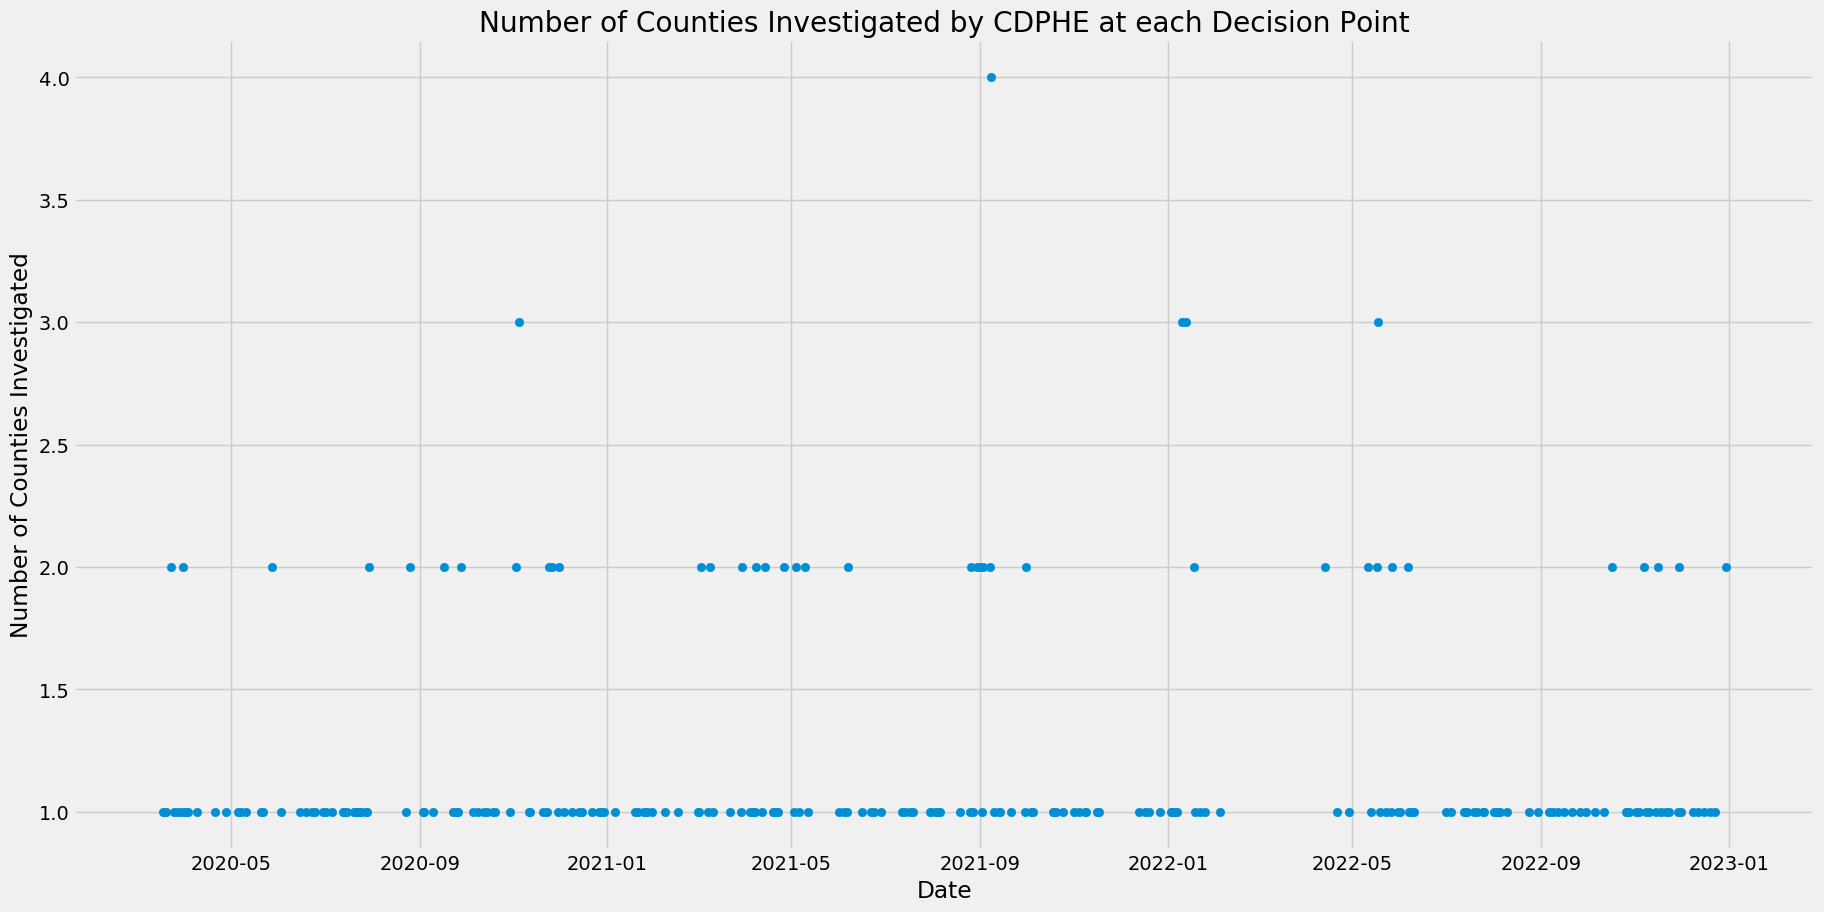

In [15]:
plt.figure(figsize=(20,10))
mask = (capacity_df["capacity"] > 0) & (capacity_df["datetime"] <= pd.to_datetime("2022-12-31") )
plt.scatter(capacity_df[mask]["datetime"], capacity_df[mask]["capacity"])
plt.ylabel("Number of Counties Investigated")
plt.xlabel("Date")
plt.title("Number of Counties Investigated by CDPHE at each Decision Point")

In [16]:
### CDPHE Capacity per DP
CDPHE_capacity_counts = pd.DataFrame(capacity_df["capacity"].value_counts())
CDPHE_capacity_counts = CDPHE_capacity_counts.sort_index()
CDPHE_capacity_counts

,capacity
0.0,784
1.0,192
2.0,37
3.0,4
4.0,1


### Plot Threshold Against Capacity

In [42]:
thresh_cap = pd.merge(colorado_TLGRF, capacity_df, how="right", left_on="date.x", right_on="datetime")
thresh_cap["rank_unfiltered"] = thresh_cap.groupby("date.x")["predictor"].rank(method="dense", ascending=False)


overall_thresh = pd.merge(thresh_cap, changepoint_panel_df, how="left", left_on=["date.x", "fips"], right_on=["datetime","fips"])
overall_thresh = pd.merge(overall_thresh, outbreak_matrix_df, how="left", left_on=["date.x", "fips"], right_on=["datetime","fips"])

overall_thresh = overall_thresh[(overall_thresh["outbreak"] == 0) | (overall_thresh["changepoint"] == 1)]
overall_thresh = overall_thresh.drop(["datetime", "datetime_x", "datetime_y"], axis=1)
overall_thresh["rank_filtered"] =   overall_thresh.groupby("date.x")["predictor"].rank(method="dense", ascending=False)
overall_thresh["delta_ranked"] = overall_thresh.groupby("date.x")["delta cases"].rank(method="dense", ascending=False)
overall_thresh

,fips,county_x,state_x,date.x,tau.hat,log_rolled_cases,shifted_log_rolled_cases,rolled_cases,shifted_rolled_cases,predictor,delta cases,capacity,rank_unfiltered,changepoint,outbreak,rank_filtered,delta_ranked
0,8031.0,Denver,Colorado,2020-03-18,0.253478,3.306363,4.857595,27.285714,128.714286,6.916333,101.428571,1.0,1.0,0.0,0.0,1.0,1.0
1,8037.0,Eagle,Colorado,2020-03-18,0.246840,3.235873,4.406719,25.428571,82.000000,6.276791,56.571429,1.0,2.0,0.0,0.0,2.0,2.0
2,8031.0,Denver,Colorado,2020-03-19,0.267161,3.547151,5.058972,34.714286,157.428571,9.274309,122.714286,1.0,1.0,0.0,0.0,1.0,1.0
3,8037.0,Eagle,Colorado,2020-03-19,0.253065,3.438585,4.561368,31.142857,95.714286,7.881172,64.571429,1.0,2.0,0.0,0.0,2.0,2.0
4,8031.0,Denver,Colorado,2020-03-20,0.250975,3.774402,5.250776,43.571429,190.714286,10.935347,147.142857,1.0,1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43294,8081.0,Moffat,Colorado,2022-12-24,-0.041047,3.761200,3.479040,43.000000,32.428571,-1.765038,-10.571429,0.0,18.0,0.0,0.0,11.0,11.0
43299,8093.0,Park,Colorado,2022-12-24,0.011629,3.645077,3.674491,38.285714,39.428571,0.445230,1.142857,0.0,6.0,0.0,0.0,3.0,4.0
43300,8097.0,Pitkin,Colorado,2022-12-24,0.001920,3.825531,3.894732,45.857143,49.142857,0.088050,3.285714,0.0,9.0,0.0,0.0,5.0,3.0
43303,8103.0,Rio Blanco,Colorado,2022-12-24,-0.029674,3.213145,3.247047,24.857143,25.714286,-0.737601,0.857143,0.0,13.0,0.0,0.0,8.0,5.0


In [43]:
#filtered_thresh = overall_thresh[(overall_thresh["outbreak"] == 0) | (overall_thresh["changepoint"] == 1)]



In [44]:
def metrics_with_threshold(df, threshold=5):
    selected_df = df[df["predictor"] >= 5]
    # Compute TP, TN, FP, FN
    #Total Positive
    Results_Thresh = pd.DataFrame()
    P = selected_df.groupby('date.x')["rank_filtered"].count()
    Results_Thresh["P"] = P
    #TP
    TP = selected_df.groupby('date.x').apply(lambda x: (x['delta_ranked'] <= len(x)).sum())
    Results_Thresh["TP"] = TP
    #FP = FN
    FP = selected_df.groupby('date.x').apply(lambda x: (x['delta_ranked'] > len(x)).sum())
    Results_Thresh["FP"] = FP
    Results_Thresh["FN"] = FP
    #N
    Total_Decision_Set = df.groupby('date.x')["rank_filtered"].count()
    Results_Thresh["Total"] = Total_Decision_Set
    Results_Thresh["N"] = Results_Thresh["Total"] - Results_Thresh["P"]
    Results_Thresh["TN"] = Results_Thresh["N"] - Results_Thresh["FN"]
    #TN
    Results_Thresh = Results_Thresh[["Total", "P", "N", "TP", "FP", "FN", "TN"]]
    
    TP = Results_Thresh.sum()["TP"]
    FP = Results_Thresh.sum()["FP"]
    FN = Results_Thresh.sum()["FN"]
    TN = Results_Thresh.sum()["TN"]


    PPV = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    FPV = Results_Thresh.sum()["FP"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])
    TPR = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    TNR = Results_Thresh.sum()["TN"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])

    Precision = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    Recall = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    F1 = 2 * Precision * Recall / (Precision + Recall)

    # create a pandas dataframe from the confusion matrix values
    confusion_table = pd.DataFrame({'actual_positive': [1, 1, 0, 0], 'predicted_positive': [0, 1, 0, 1], 'count': [FN, TP, TN, FP]})

    # create a pivot table to represent the confusion matrix
    confusion_matrix = pd.pivot_table(confusion_table, values='count', index=['actual_positive'], columns=['predicted_positive'])

    # set the column and index names of the pivot table
    confusion_matrix.columns.name = 'Predicted Label'
    confusion_matrix.index.name = 'Actual Label'


    print("PPV={}, FPV={}\nTPR={}, TNR={}\nF1={}".format(PPV, FPV, TPR, TNR, F1))
    confusion_matrix
    
    return Results_Thresh, (PPV, FPV, TPR, TNR, F1), confusion_matrix

In [45]:
metrics_with_threshold(overall_thresh, 5)

PPV=0.7485754985754985, FPV=0.04790337902021984
TPR=0.7485754985754985, TNR=0.9520966209797802
F1=0.7485754985754985


(            Total  P   N  TP  FP  FN  TN
 date.x                                  
 2020-03-18      2  2   0   2   0   0   0
 2020-03-19      2  2   0   2   0   0   0
 2020-03-20      2  2   0   2   0   0   0
 2020-03-21      3  3   0   3   0   0   0
 2020-03-22      3  3   0   3   0   0   0
 ...           ... ..  ..  ..  ..  ..  ..
 2022-12-10     16  1  15   0   1   1  14
 2022-12-11     16  1  15   0   1   1  14
 2022-12-12     16  1  15   0   1   1  14
 2022-12-13     15  1  14   0   1   1  13
 2022-12-14     16  1  15   0   1   1  14
 
 [628 rows x 7 columns],
 (0.7485754985754985,
  0.04790337902021984,
  0.7485754985754985,
  0.9520966209797802,
  0.7485754985754985),
 Predicted Label     0     1
 Actual Label               
 0                7016   353
 1                 353  1051)

Text(0.5, 1.0, 'Number of Investigations at All Datetime CDPHE vs Threshold')

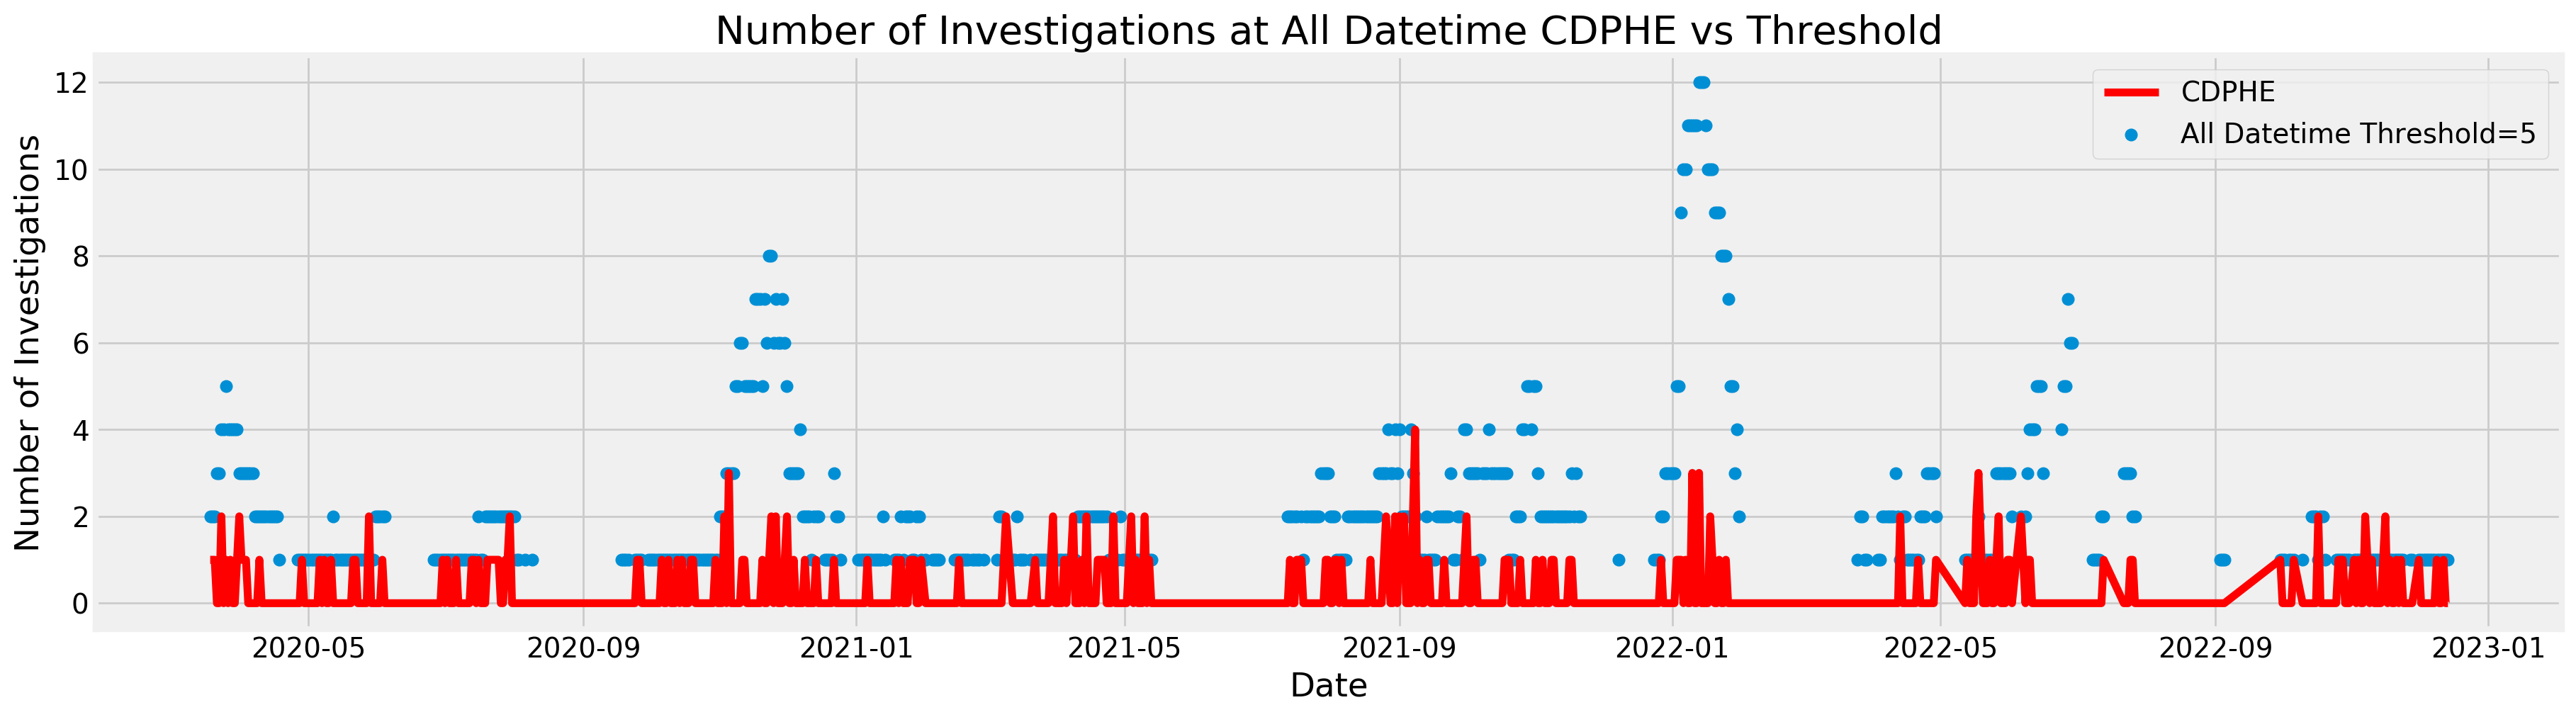

In [46]:
# Change to scatters
fig, ax = plt.subplots(1,1,figsize=(20,5), dpi= 200, facecolor='w', edgecolor='k')
selected_df = overall_thresh[overall_thresh["predictor"] >= 5]
all_selected = selected_df.groupby("date.x")["rank_filtered"].count()
plt.plot(capacity_df[capacity_df["datetime"].isin(all_selected.index)]["datetime"], capacity_df[capacity_df["datetime"].isin(all_selected.index)]["capacity"], label="CDPHE", color='r')
plt.scatter(all_selected.index, all_selected, label="All Datetime Threshold=5")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Number of Investigations")
plt.title("Number of Investigations at All Datetime CDPHE vs Threshold")

In [47]:
all_selected_value_counts = pd.DataFrame(all_selected.value_counts())
all_selected_value_counts = all_selected_value_counts.sort_index()
all_selected_value_counts["cumsum_rank_filtered"] = all_selected_value_counts["rank_filtered"].cumsum(axis=0)
all_selected_value_counts

,rank_filtered,cumsum_rank_filtered
1,300,300
2,167,467
3,75,542
4,23,565
5,23,588
6,9,597
7,8,605
8,5,610
9,4,614
10,5,619


In [48]:
all_capacity = pd.DataFrame(capacity_df[capacity_df["datetime"].isin(all_selected.index)]["capacity"].value_counts().sort_index())
all_capacity["cumsum_capacity"] = all_capacity["capacity"].cumsum(axis=0)
all_capacity

,capacity,cumsum_capacity
0.0,459,459
1.0,135,594
2.0,29,623
3.0,4,627
4.0,1,628


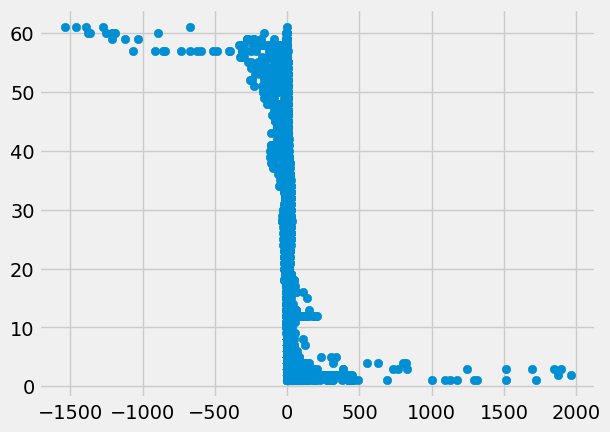

In [49]:
plt.scatter(overall_thresh["predictor"], overall_thresh["rank_unfiltered"])

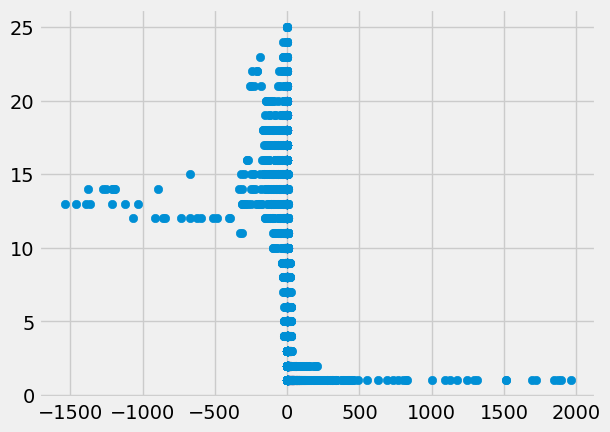

In [50]:
plt.scatter(overall_thresh["predictor"], overall_thresh["rank_filtered"])

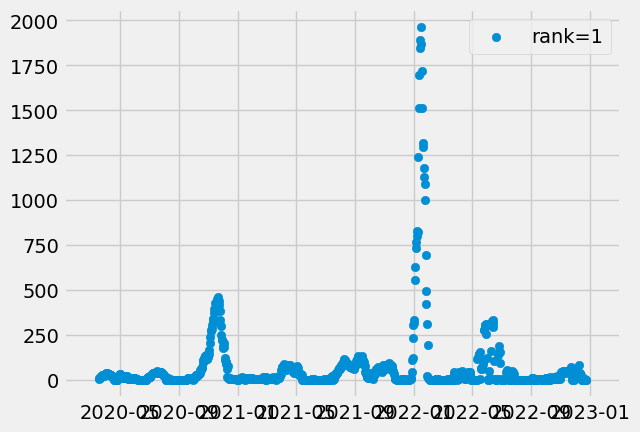

In [51]:
for rank in (range(1,2)):
    plotted_df = overall_thresh[overall_thresh["rank_filtered"]==rank]
    plotted_df.sort_values("date.x")
    plt.scatter(plotted_df["date.x"],plotted_df["predictor"], label="rank={}".format(rank))
    plt.legend()

In [52]:
plotted_df["predictor"].describe()

count    1012.000000
mean       68.429426
std       202.683751
min        -2.794032
25%         2.329823
50%        11.319857
75%        50.157790
max      1963.719839
Name: predictor, dtype: float64

Text(0.5, 1.0, 'Comparing overall ranking against ranking in white only')

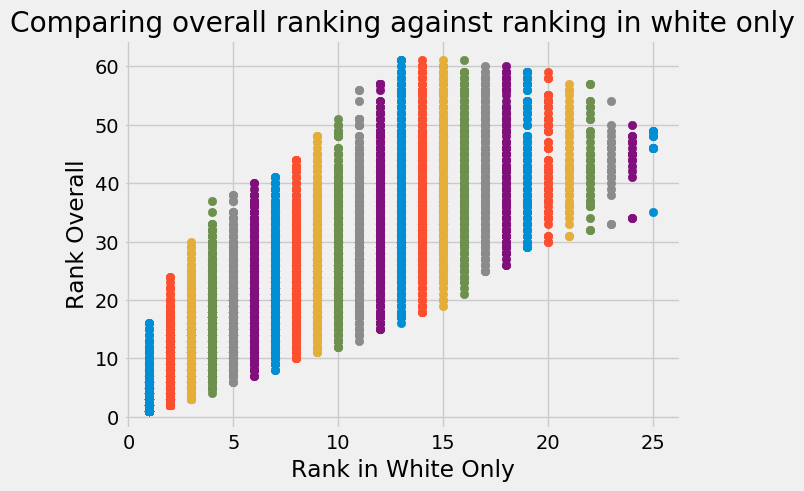

In [53]:
for rank in range(1,63):
    qq_rank_df = overall_thresh[overall_thresh["rank_filtered"] == rank]
    plt.scatter(qq_rank_df["rank_filtered"], qq_rank_df["rank_unfiltered"], label="rank={}".format(rank))
plt.xlabel("Rank in White Only")
plt.ylabel("Rank Overall")
plt.title("Comparing overall ranking against ranking in white only")

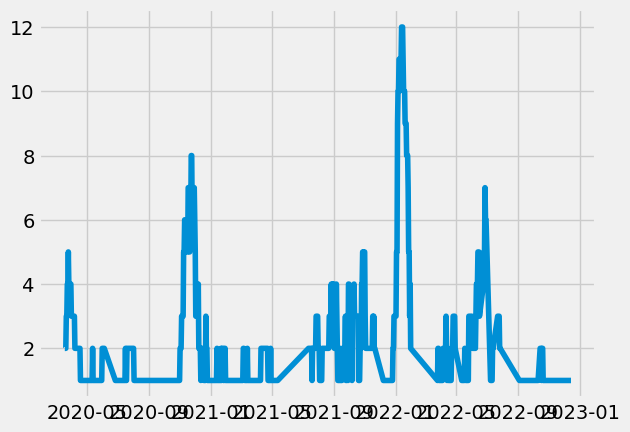

In [54]:
picked = overall_thresh[overall_thresh["predictor"] >= 5].groupby("date.x")["rank_filtered"].count()
plt.plot(picked)

In [55]:
pd.DataFrame(picked).value_counts()

rank_filtered
1                300
2                167
3                 75
4                 23
5                 23
6                  9
7                  8
11                 6
8                  5
10                 5
9                  4
12                 3
dtype: int64

In [56]:
pd.DataFrame(picked).loc["2022-01-14"]

rank_filtered    12
Name: 2022-01-14 00:00:00, dtype: int64

### Obtain Changepoints Decision Set:
`(capacity > 0) & ((outbreak == 0) | (changepoint == 1))`

In [57]:
capacity_df

,datetime,capacity
0,2020-03-18,1.0
1,2020-03-19,1.0
2,2020-03-20,1.0
3,2020-03-21,0.0
4,2020-03-22,0.0
...,...,...
1013,2022-12-26,0.0
1014,2022-12-27,0.0
1015,2022-12-28,0.0
1016,2022-12-29,0.0


In [58]:
dp_df = overall_thresh[(overall_thresh["capacity"] > 0) & ((overall_thresh["outbreak"] == 0) | (overall_thresh["changepoint"] == 1))]
dp_df["rank_filtered"] =   dp_df.groupby("date.x")["predictor"].rank(method="dense", ascending=False)
dp_df["delta_ranked"] = dp_df.groupby("date.x")["delta cases"].rank(method="dense", ascending=False)
dp_df = dp_df.sort_values(by=["date.x","rank_filtered"])
dp_df

,fips,county_x,state_x,date.x,tau.hat,log_rolled_cases,shifted_log_rolled_cases,rolled_cases,shifted_rolled_cases,predictor,delta cases,capacity,rank_unfiltered,changepoint,outbreak,rank_filtered,delta_ranked
0,8031.0,Denver,Colorado,2020-03-18,0.253478,3.306363,4.857595,27.285714,128.714286,6.916333,101.428571,1.0,1.0,0.0,0.0,1.0,1.0
1,8037.0,Eagle,Colorado,2020-03-18,0.246840,3.235873,4.406719,25.428571,82.000000,6.276791,56.571429,1.0,2.0,0.0,0.0,2.0,2.0
2,8031.0,Denver,Colorado,2020-03-19,0.267161,3.547151,5.058972,34.714286,157.428571,9.274309,122.714286,1.0,1.0,0.0,0.0,1.0,1.0
3,8037.0,Eagle,Colorado,2020-03-19,0.253065,3.438585,4.561368,31.142857,95.714286,7.881172,64.571429,1.0,2.0,0.0,0.0,2.0,2.0
4,8031.0,Denver,Colorado,2020-03-20,0.250975,3.774402,5.250776,43.571429,190.714286,10.935347,147.142857,1.0,1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43238,8029.0,Delta,Colorado,2022-12-23,-0.017627,4.460970,4.252569,86.571429,70.285714,-1.525969,-16.285714,1.0,19.0,0.0,0.0,11.0,12.0
43253,8081.0,Moffat,Colorado,2022-12-23,-0.035139,3.809832,3.509411,45.142857,33.428571,-1.586254,-11.714286,1.0,20.0,0.0,0.0,12.0,11.0
43248,8067.0,La Plata,Colorado,2022-12-23,-0.016677,5.125663,4.924143,168.285714,137.571429,-2.806479,-30.714286,1.0,26.0,0.0,0.0,13.0,14.0
43254,8083.0,Montezuma,Colorado,2022-12-23,-0.029646,4.751124,4.550865,115.714286,94.714286,-3.430459,-21.000000,1.0,28.0,1.0,1.0,14.0,13.0


In [59]:
def metrics_with_threshold(dp_df, threshold=5):
    selected_dp_df = dp_df[dp_df["predictor"] >= 5]
    # Compute TP, TN, FP, FN
    #Total Positive
    Results_Thresh = pd.DataFrame()
    P = selected_dp_df.groupby('date.x')["rank_filtered"].count()
    Results_Thresh["P"] = P
    #TP
    TP = selected_dp_df.groupby('date.x').apply(lambda x: (x['delta_ranked'] <= len(x)).sum())
    Results_Thresh["TP"] = TP
    #FP = FN
    FP = selected_dp_df.groupby('date.x').apply(lambda x: (x['delta_ranked'] > len(x)).sum())
    Results_Thresh["FP"] = FP
    Results_Thresh["FN"] = FP
    #N
    Total_Decision_Set = dp_df.groupby('date.x')["rank_filtered"].count()
    Results_Thresh["Total"] = Total_Decision_Set
    Results_Thresh["N"] = Results_Thresh["Total"] - Results_Thresh["P"]
    Results_Thresh["TN"] = Results_Thresh["N"] - Results_Thresh["FN"]
    #TN
    Results_Thresh = Results_Thresh[["Total", "P", "N", "TP", "FP", "FN", "TN"]]
    
    TP = Results_Thresh.sum()["TP"]
    FP = Results_Thresh.sum()["FP"]
    FN = Results_Thresh.sum()["FN"]
    TN = Results_Thresh.sum()["TN"]


    PPV = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    FPV = Results_Thresh.sum()["FP"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])
    TPR = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    TNR = Results_Thresh.sum()["TN"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])

    Precision = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    Recall = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    F1 = 2 * Precision * Recall / (Precision + Recall)

    # create a pandas dataframe from the confusion matrix values
    confusion_table = pd.DataFrame({'actual_positive': [1, 1, 0, 0], 'predicted_positive': [0, 1, 0, 1], 'count': [FN, TP, TN, FP]})

    # create a pivot table to represent the confusion matrix
    confusion_matrix = pd.pivot_table(confusion_table, values='count', index=['actual_positive'], columns=['predicted_positive'])

    # set the column and index names of the pivot table
    confusion_matrix.columns.name = 'Predicted Label'
    confusion_matrix.index.name = 'Actual Label'


    print("PPV={}, FPV={}\nTPR={}, TNR={}\nF1={}".format(PPV, FPV, TPR, TNR, F1))
    confusion_matrix
    
    return Results_Thresh, (PPV, FPV, TPR, TNR, F1), confusion_matrix

In [60]:
Results_Thresh = metrics_with_threshold(dp_df, 5)
Results_Thresh

PPV=0.8205741626794258, FPV=0.03920543648719289
TPR=0.8205741626794258, TNR=0.9607945635128071
F1=0.8205741626794258


(            Total  P   N  TP  FP  FN  TN
 date.x                                  
 2020-03-18      2  2   0   2   0   0   0
 2020-03-19      2  2   0   2   0   0   0
 2020-03-20      2  2   0   2   0   0   0
 2020-03-23      4  4   0   4   0   0   0
 2020-03-25      5  5   0   5   0   0   0
 ...           ... ..  ..  ..  ..  ..  ..
 2022-11-21     14  1  13   1   0   0  13
 2022-11-23     13  1  12   1   0   0  12
 2022-12-01     17  1  16   1   0   0  16
 2022-12-09     17  1  16   0   1   1  15
 2022-12-12     16  1  15   0   1   1  14
 
 [169 rows x 7 columns],
 (0.8205741626794258,
  0.03920543648719289,
  0.8205741626794258,
  0.9607945635128071,
  0.8205741626794258),
 Predicted Label     0    1
 Actual Label              
 0                1838   75
 1                  75  343)

Text(0.5, 1.0, 'Number of Investigations at each Decision Point CDPHE vs Threshold')

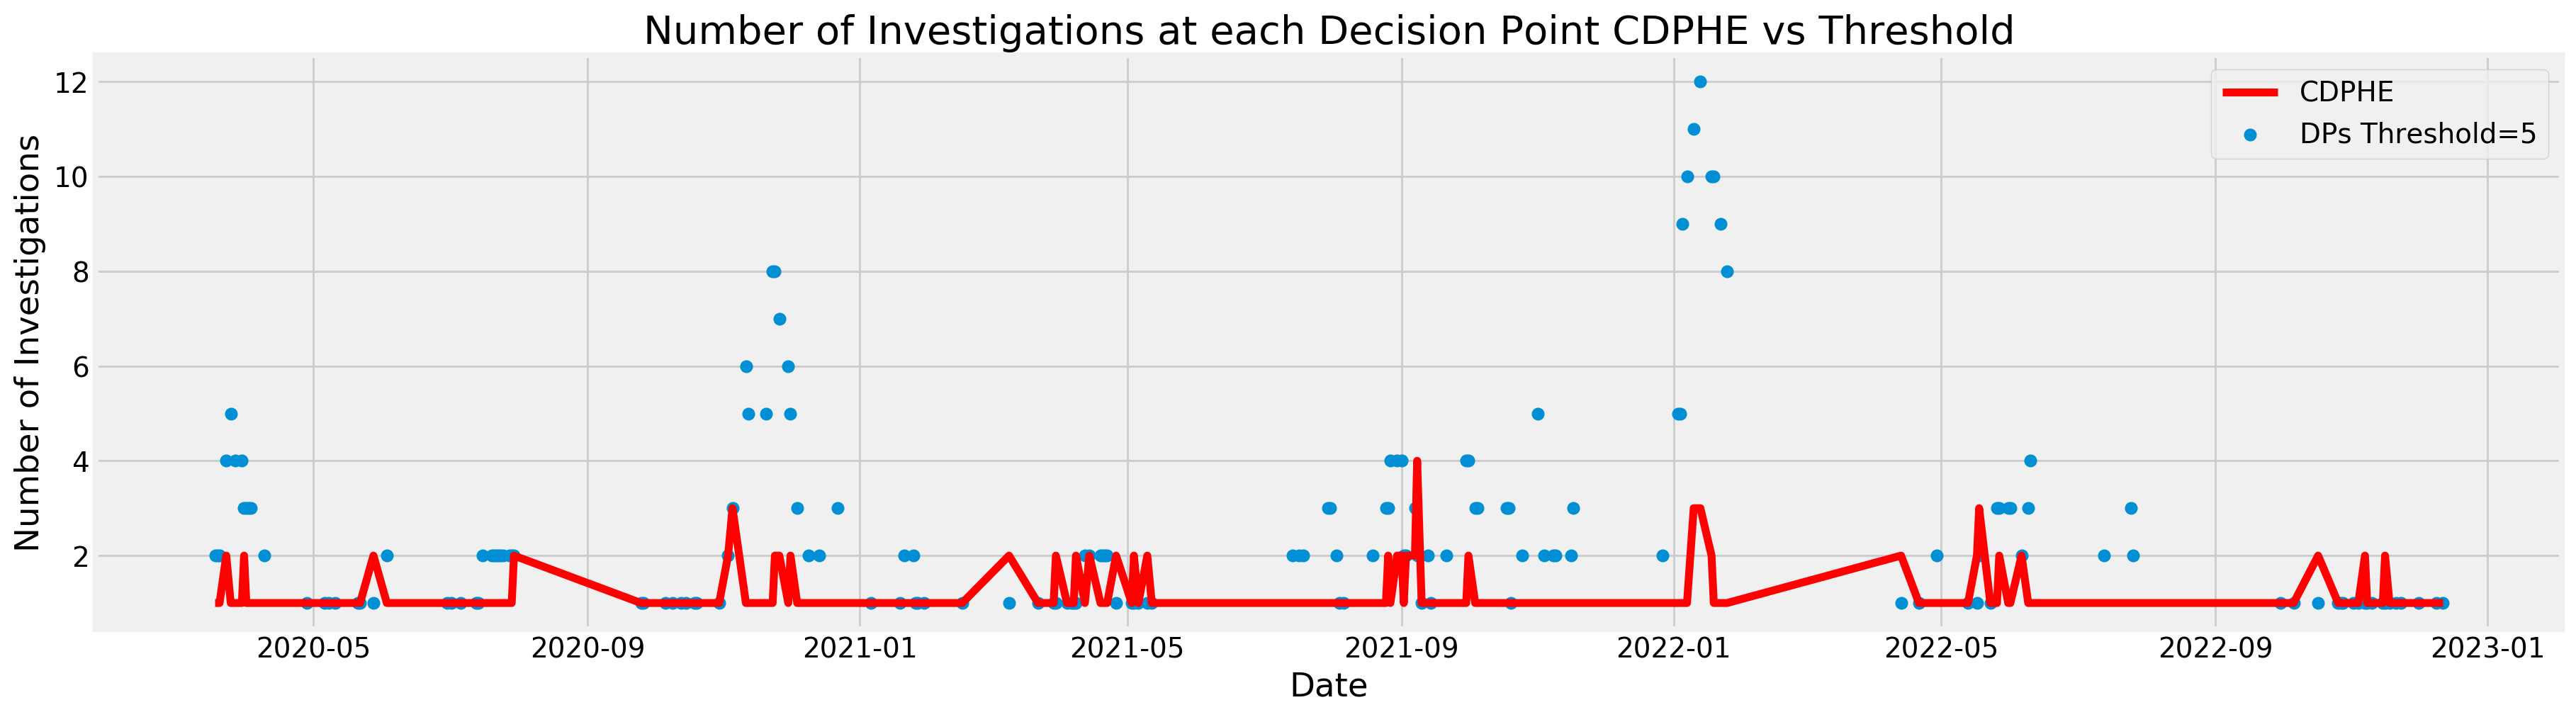

In [61]:
# Change to scatters
fig, ax = plt.subplots(1,1,figsize=(20,5), dpi= 200, facecolor='w', edgecolor='k')
selected_dp_df = dp_df[dp_df["predictor"] >= 5]
selected = selected_dp_df.groupby("date.x")["rank_filtered"].count()
plt.scatter(selected.index, selected, label="DPs Threshold=5")
plt.plot(capacity_df[capacity_df["datetime"].isin(selected.index)]["datetime"], capacity_df[capacity_df["datetime"].isin(selected.index)]["capacity"], label="CDPHE", color='r')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Number of Investigations")
plt.title("Number of Investigations at each Decision Point CDPHE vs Threshold")

Text(0.5, 1.0, 'Number of Investigations at each Decision Point CDPHE vs Threshold')

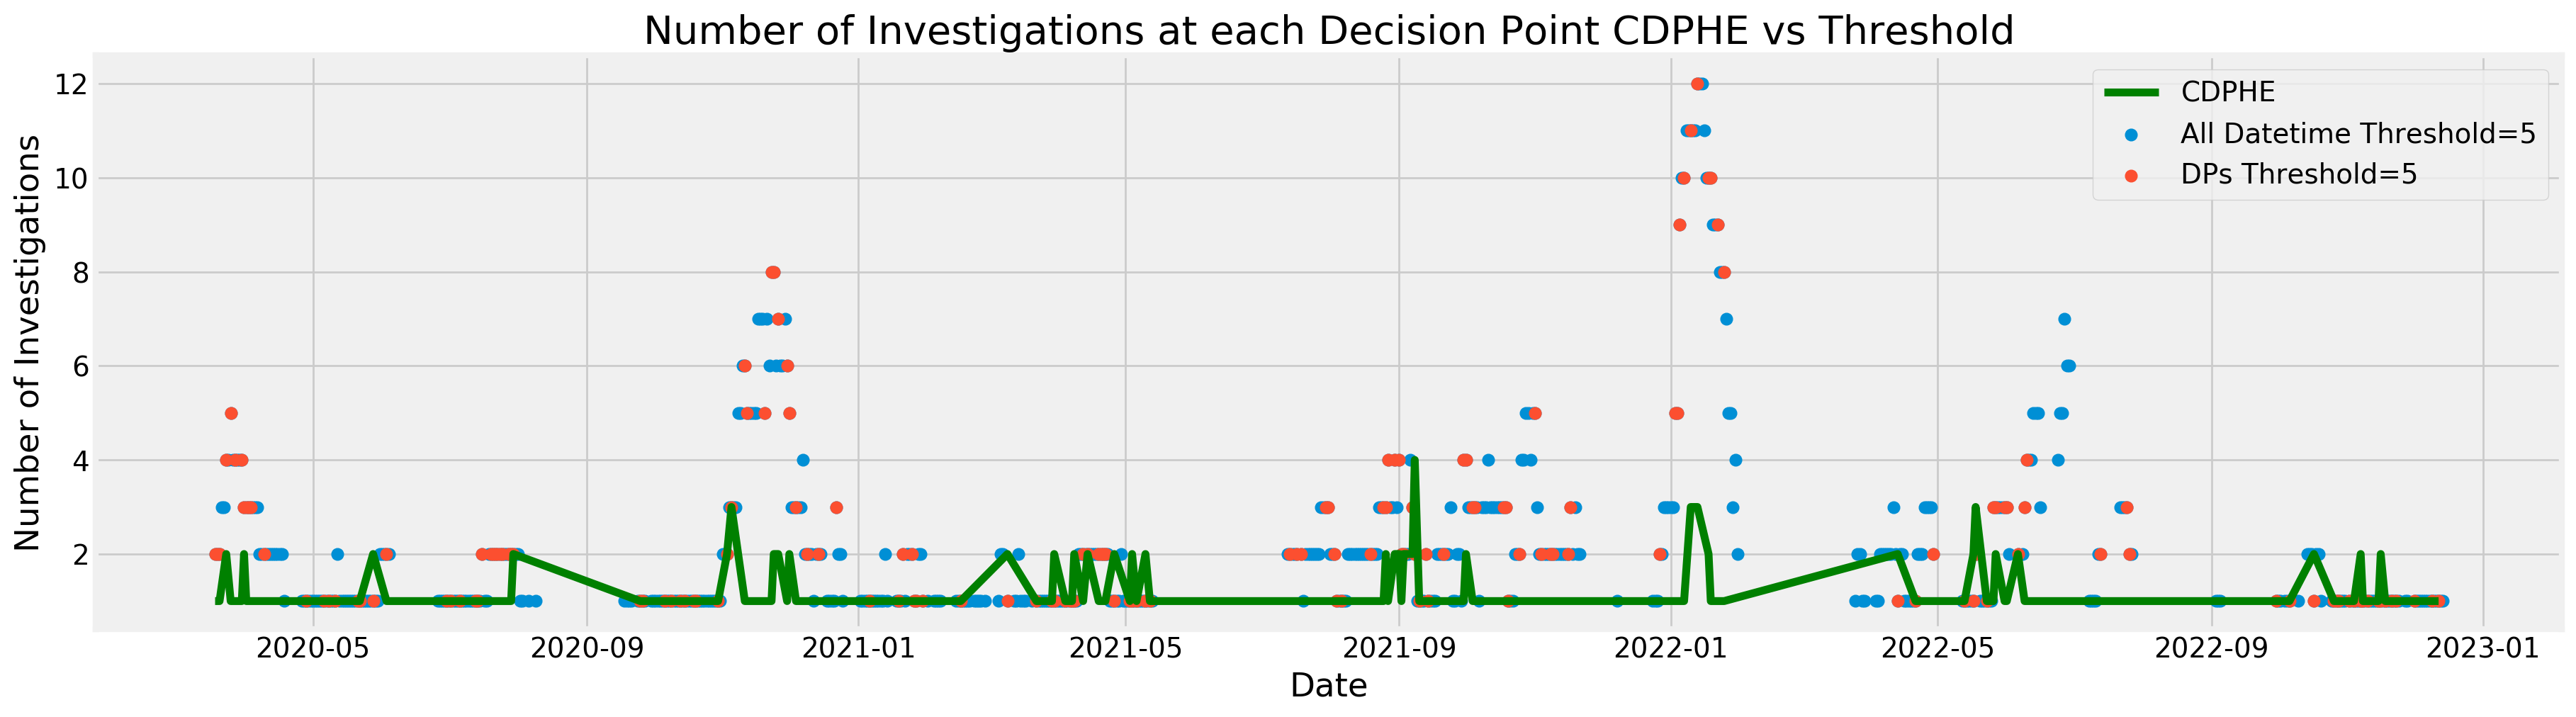

In [62]:
# Change to scatters
fig, ax = plt.subplots(1,1,figsize=(20,5), dpi= 200, facecolor='w', edgecolor='k')
selected_dp_df = dp_df[dp_df["predictor"] >= 5]
selected = selected_dp_df.groupby("date.x")["rank_filtered"].count()
plt.scatter(all_selected.index, all_selected, label="All Datetime Threshold=5")
plt.scatter(selected.index, selected, label="DPs Threshold=5")
plt.plot(capacity_df[capacity_df["datetime"].isin(selected.index)]["datetime"], capacity_df[capacity_df["datetime"].isin(selected.index)]["capacity"], label="CDPHE", color='g')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Number of Investigations")
plt.title("Number of Investigations at each Decision Point CDPHE vs Threshold")

In [63]:
selected.index

DatetimeIndex(['2020-03-18', '2020-03-19', '2020-03-20', '2020-03-23',
               '2020-03-25', '2020-03-27', '2020-03-30', '2020-03-31',
               '2020-04-01', '2020-04-02',
               ...
               '2022-11-08', '2022-11-10', '2022-11-15', '2022-11-16',
               '2022-11-18', '2022-11-21', '2022-11-23', '2022-12-01',
               '2022-12-09', '2022-12-12'],
              dtype='datetime64[ns]', name='date.x', length=169, freq=None)

In [64]:
selected_value_counts = pd.DataFrame(selected.value_counts())
selected_value_counts = selected_value_counts.sort_index()
#selected_value_counts["cumsum_rank_filtered"] = selected_value_counts["rank_filtered"].cumsum(axis=0)
selected_value_counts

,rank_filtered
1,70
2,47
3,23
4,9
5,7
6,2
7,1
8,3
9,2
10,3


In [65]:
capacity_df[capacity_df["datetime"].isin(selected.index)]["capacity"].value_counts().sort_index()

1.0    135
2.0     29
3.0      4
4.0      1
Name: capacity, dtype: int64

### Evaluate CDPHE and TLGRF

In [66]:
dp_df.to_csv("../data/CDPHE_TLGRF_historical.csv", index=False)

In [72]:
changepoint_panel_df[(changepoint_panel_df["datetime"] == "2020-03-23") & (changepoint_panel_df["changepoint"] == 1)]

,datetime,fips,changepoint
6,2020-03-23,8001,1.0
34056,2020-03-23,8059,1.0


In [75]:
overall_thresh[overall_thresh["date.x"] == "2020-03-23"]

,fips,county_x,state_x,date.x,tau.hat,log_rolled_cases,shifted_log_rolled_cases,rolled_cases,shifted_rolled_cases,predictor,delta cases,capacity,rank_unfiltered,changepoint,outbreak,rank_filtered,delta_ranked
14,8031.0,Denver,Colorado,2020-03-23,0.228447,4.446007,5.749393,85.285714,314.000000,19.483248,228.714286,2.0,1.0,0.0,0.0,1.0,1.0
15,8037.0,Eagle,Colorado,2020-03-23,0.198125,4.120198,5.068005,61.571429,158.857143,12.198821,97.285714,2.0,2.0,0.0,0.0,2.0,4.0
16,8041.0,El Paso,Colorado,2020-03-23,0.270250,3.415382,5.114566,30.428571,166.428571,8.223314,136.000000,2.0,3.0,0.0,0.0,3.0,2.0
17,8059.0,Jefferson,Colorado,2020-03-23,0.201594,3.630039,5.056246,37.714286,157.000000,7.602956,119.285714,2.0,4.0,1.0,1.0,4.0,3.0


In [78]:
colorado_TLGRF[colorado_TLGRF["date.x"]=="2020-03-23"]

,fips,county_x,state_x,date.x,tau.hat,log_rolled_cases,shifted_log_rolled_cases,rolled_cases,shifted_rolled_cases,predictor,delta cases
25685,8005.0,Arapahoe,Colorado,2020-03-23,0.224744,3.509411,5.130744,33.428571,169.142857,7.512883,135.714286
34603,8031.0,Denver,Colorado,2020-03-23,0.228447,4.446007,5.749393,85.285714,314.000000,19.483248,228.714286
36714,8037.0,Eagle,Colorado,2020-03-23,0.198125,4.120198,5.068005,61.571429,158.857143,12.198821,97.285714
38587,8041.0,El Paso,Colorado,2020-03-23,0.270250,3.415382,5.114566,30.428571,166.428571,8.223314,136.000000
43902,8059.0,Jefferson,Colorado,2020-03-23,0.201594,3.630039,5.056246,37.714286,157.000000,7.602956,119.285714
